In [2]:
using LinearAlgebra
using Plots

gr()

Plots.GRBackend()

In [3]:
function gradient_descent(f, grad_f, x0, alpha, max_iter=1000, tol=1e-6; run_label="", verbose=true)
    x = copy(x0)
    history = [(x=copy(x), f=f(x), iter=0)]
    converged = false
    
    for i in 1:max_iter
        grad = grad_f(x)
        
        if norm(grad) < tol
            converged = true
            if verbose
                prefix = isempty(run_label) ? "" : "[" * run_label * "] "
                println(prefix * "Сходимость достигнута на итерации " * string(i))
            end
            break
        end
        
        x = x - alpha * grad

        push!(history, (x=copy(x), f=f(x), iter=i))
    end
    
    if verbose && !converged
        prefix = isempty(run_label) ? "" : "[" * run_label * "] "
        println(prefix * "Сходимость не достигнута за " * string(max_iter) * " итераций; ||grad|| = " * string(norm(grad_f(x))))
    end

    return x, history
end

gradient_descent (generic function with 3 methods)

In [4]:
function line_search(f, grad_f, x, direction;
                     alpha_init=1.0,
                     alpha_max=100.0,
                     tol_ls=1e-6,
                     max_iter_ls=80)
    if norm(direction) < 1e-14
        return 0.0
    end

    g(alpha) = f(x + alpha * direction)

    left = 0.0
    right = alpha_init
    g_left = g(left)
    g_right = g(right)

    while g_right < g_left && right < alpha_max
        left = right
        g_left = g_right
        right = min(2.0 * right, alpha_max)
        g_right = g(right)
    end

    if right == alpha_max && g_right < g_left
        return right
    end

    a = 0.0
    b = right
    tau = (sqrt(5.0) - 1.0) / 2.0

    c1 = b - tau * (b - a)
    c2 = a + tau * (b - a)
    g1 = g(c1)
    g2 = g(c2)

    for _ in 1:max_iter_ls
        if abs(b - a) < tol_ls
            break
        end

        if g1 > g2
            a = c1
            c1 = c2
            g1 = g2
            c2 = a + tau * (b - a)
            g2 = g(c2)
        else
            b = c2
            c2 = c1
            g2 = g1
            c1 = b - tau * (b - a)
            g1 = g(c1)
        end
    end

    return (a + b) / 2.0
end

function steepest_descent(f, grad_f, x0, max_iter=1000, tol=1e-6; run_label="", verbose=true)
    x = copy(x0)
    history = [(x=copy(x), f=f(x), iter=0, alpha=0.0)]
    converged = false
    
    for i in 1:max_iter
        grad = grad_f(x)
        
        if norm(grad) < tol
            converged = true
            if verbose
                prefix = isempty(run_label) ? "" : "[" * run_label * "] "
                println(prefix * "Сходимость достигнута на итерации " * string(i))
            end
            break
        end
        
        direction = -grad
        
        alpha = line_search(f, grad_f, x, direction)
        
        x = x + alpha * direction
        
        push!(history, (x=copy(x), f=f(x), iter=i, alpha=alpha))
    end
    
    if verbose && !converged
        prefix = isempty(run_label) ? "" : "[" * run_label * "] "
        println(prefix * "Сходимость не достигнута за " * string(max_iter) * " итераций; ||grad|| = " * string(norm(grad_f(x))))
    end

    return x, history
end


steepest_descent (generic function with 3 methods)

In [5]:
function conjugate_gradient(f, grad_f, x0, max_iter=1000, tol=1e-6; run_label="", verbose=true)
    x = copy(x0)
    grad = grad_f(x)
    direction = -grad
    history = [(x=copy(x), f=f(x), iter=0, alpha=0.0, beta=0.0)]
    converged = false
    
    for i in 1:max_iter
        if norm(grad) < tol
            converged = true
            if verbose
                prefix = isempty(run_label) ? "" : "[" * run_label * "] "
                println(prefix * "Сходимость достигнута на итерации " * string(i))
            end
            break
        end
        
        alpha = line_search(f, grad_f, x, direction)
        
        x_new = x + alpha * direction
        grad_new = grad_f(x_new)
        
        grad_diff = grad_new - grad
        beta = max(0, dot(grad_new, grad_diff) / dot(grad, grad))
        
        direction = -grad_new + beta * direction
        
        x = x_new
        grad = grad_new
        
        push!(history, (x=copy(x), f=f(x), iter=i, alpha=alpha, beta=beta))
    end
    
    if verbose && !converged
        prefix = isempty(run_label) ? "" : "[" * run_label * "] "
        println(prefix * "Сходимость не достигнута за " * string(max_iter) * " итераций; ||grad|| = " * string(norm(grad)))
    end

    return x, history
end

conjugate_gradient (generic function with 3 methods)

In [6]:
function history_xy(history)
    xs = [h.x[1] for h in history]
    ys = [h.x[2] for h in history]
    return xs, ys
end

function plot_trajectories_on_contour(f, histories, title_text;
                                      xlims=(-5.0, 5.0),
                                      ylims=(-5.0, 5.0),
                                      levels=25,
                                      grid_n=180,
                                      auto_zoom=false,
                                      zoom_pad=0.2,
                                      min_span=5.0,
                                      zoom_max_points=200)
    if auto_zoom
        all_x = Float64[]
        all_y = Float64[]
        for (_, hist) in histories
            n = min(length(hist), zoom_max_points)
            hist_part = hist[1:n]
            append!(all_x, [h.x[1] for h in hist_part])
            append!(all_y, [h.x[2] for h in hist_part])
        end
        xmin, xmax = minimum(all_x), maximum(all_x)
        ymin, ymax = minimum(all_y), maximum(all_y)
        xspan = max(xmax - xmin, min_span)
        yspan = max(ymax - ymin, min_span)
        xpad = zoom_pad * xspan
        ypad = zoom_pad * yspan
        xlims = (xmin - xpad, xmax + xpad)
        ylims = (ymin - ypad, ymax + ypad)
    end

    xr = LinRange(xlims[1], xlims[2], grid_n)
    yr = LinRange(ylims[1], ylims[2], grid_n)
    Z = [f([x, y]) for y in yr, x in xr]

    p = contour(xr, yr, Z;
                levels=levels,
                color=:grays,
                colorbar=false,
                xlabel="x1",
                ylabel="x2",
                title=title_text,
                aspect_ratio=:equal,
                xlims=xlims,
                ylims=ylims,
                legend=:outerbottom,
                legend_column=2)

    colors = [:blue, :green, :orange]
    markers = [:circle, :square, :diamond]

    i = 1
    for (name, hist) in histories
        xs, ys = history_xy(hist)
        plot!(p, xs, ys;
              label=name,
              linewidth=2,
              marker=markers[i],
              markersize=3,
              color=colors[i])

        n_first = min(length(xs), 6)
        scatter!(p, xs[1:n_first], ys[1:n_first];
                 label="",
                 markersize=5,
                 marker=markers[i],
                 markerstrokewidth=1.5,
                 markerstrokecolor=:black,
                 color=colors[i])

        if length(xs) > 1
            dx = xs[2] - xs[1]
            dy = ys[2] - ys[1]
            quiver!(p, [xs[1]], [ys[1]];
                    quiver=([dx], [dy]),
                    label="",
                    color=colors[i],
                    linewidth=2)
        end

        i += 1
    end

    x0 = histories[1][2][1].x
    scatter!(p, [x0[1]], [x0[2]];
             label="Начальная точка",
             color=:red,
             markersize=5)

    return p
end

plot_trajectories_on_contour (generic function with 1 method)

[Quadratic beta=1 | Градиентный спуск (фикс. шаг)] Сходимость достигнута на итерации 142
[Quadratic beta=1 | Наискорейший спуск] Сходимость достигнута на итерации 2
[Quadratic beta=1 | Сопряженные градиенты] Сходимость достигнута на итерации 2
[Quadratic beta=5 | Градиентный спуск (фикс. шаг)] Сходимость достигнута на итерации 139
[Quadratic beta=5 | Наискорейший спуск] Сходимость достигнута на итерации 16
[Quadratic beta=5 | Сопряженные градиенты] Сходимость достигнута на итерации 4
[Quadratic beta=10 | Градиентный спуск (фикс. шаг)] Сходимость достигнута на итерации 139
[Quadratic beta=10 | Наискорейший спуск] Сходимость достигнута на итерации 14
[Quadratic beta=10 | Сопряженные градиенты] Сходимость достигнута на итерации 4


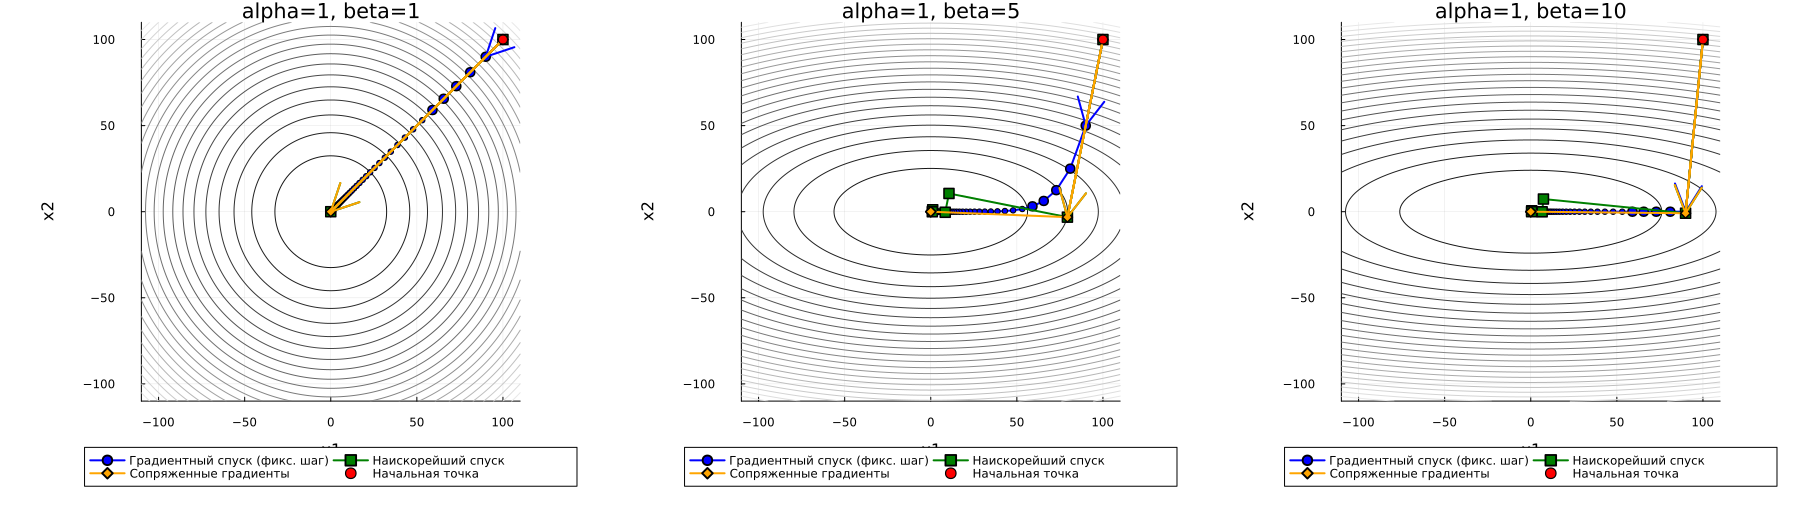

In [7]:
alpha_q = 1.0
betas = [1.0, 5.0, 10.0]
x0_quad = [100.0, 100.0]

fixed_step_quad = 0.05
max_iter_quad = 3000
tol_quad = 1e-4

plots_quad = Any[]

for beta_q in betas
    f_quad(x) = alpha_q * x[1]^2 + beta_q * x[2]^2
    grad_quad(x) = [2 * alpha_q * x[1], 2 * beta_q * x[2]]

    _, hist_gd = gradient_descent(
        f_quad, grad_quad, x0_quad, fixed_step_quad, max_iter_quad, tol_quad;
        run_label="Quadratic beta=$(Int(beta_q)) | Градиентный спуск (фикс. шаг)"
    )
    _, hist_sd = steepest_descent(
        f_quad, grad_quad, x0_quad, max_iter_quad, tol_quad;
        run_label="Quadratic beta=$(Int(beta_q)) | Наискорейший спуск"
    )
    _, hist_cg = conjugate_gradient(
        f_quad, grad_quad, x0_quad, max_iter_quad, tol_quad;
        run_label="Quadratic beta=$(Int(beta_q)) | Сопряженные градиенты"
    )

    histories = [
        ("Градиентный спуск (фикс. шаг)", hist_gd),
        ("Наискорейший спуск", hist_sd),
        ("Сопряженные градиенты", hist_cg)
    ]

    p = plot_trajectories_on_contour(
        f_quad,
        histories,
        "alpha=1, beta=$(Int(beta_q))";
        xlims=(-110.0, 110.0),
        ylims=(-110.0, 110.0),
        levels=22,
        grid_n=170
    )

    push!(plots_quad, p)
end

plot(plots_quad...; layout=(1, 3), size=(1800, 520))

In [8]:
rosenbrock(x) = (1 - x[1])^2 + 100 * (x[2] - x[1]^2)^2

function grad_rosenbrock(x)
    g1 = -2 * (1 - x[1]) - 400 * x[1] * (x[2] - x[1]^2)
    g2 = 200 * (x[2] - x[1]^2)
    return [g1, g2]
end

function rastrigin(x)
    A = 10.0
    return 2A + (x[1]^2 - A * cos(2 * pi * x[1])) + (x[2]^2 - A * cos(2 * pi * x[2]))
end

function grad_rastrigin(x)
    A = 10.0
    g1 = 2 * x[1] + 2 * pi * A * sin(2 * pi * x[1])
    g2 = 2 * x[2] + 2 * pi * A * sin(2 * pi * x[2])
    return [g1, g2]
end

function schwefel(x)
    c = 418.9829
    return 2c - (x[1] * sin(sqrt(abs(x[1]))) + x[2] * sin(sqrt(abs(x[2]))))
end

function grad_schwefel(x)
    g = zeros(2)
    for i in 1:2
        xi = x[i]
        s = sqrt(abs(xi) + 1e-12)
        d_term = sin(s) + xi * cos(s) * sign(xi) / (2s)
        g[i] = -d_term
    end
    return g
end

grad_schwefel (generic function with 1 method)

[Rosenbrock | Градиентный спуск (фикс. шаг)] Сходимость не достигнута за 5000 итераций; ||grad|| = 0.047155412977206865
[Rosenbrock | Наискорейший спуск] Сходимость достигнута на итерации 3040
[Rosenbrock | Сопряженные градиенты] Сходимость достигнута на итерации 14
[Rastrigin | Градиентный спуск (фикс. шаг)] Сходимость не достигнута за 5000 итераций; ||grad|| = 77.04269069335142
[Rastrigin | Наискорейший спуск] Сходимость достигнута на итерации 3
[Rastrigin | Сопряженные градиенты] Сходимость достигнута на итерации 4
[Schwefel | Градиентный спуск (фикс. шаг)] Сходимость достигнута на итерации 1198
[Schwefel | Наискорейший спуск] Сходимость достигнута на итерации 6
[Schwefel | Сопряженные градиенты] Сходимость достигнута на итерации 7


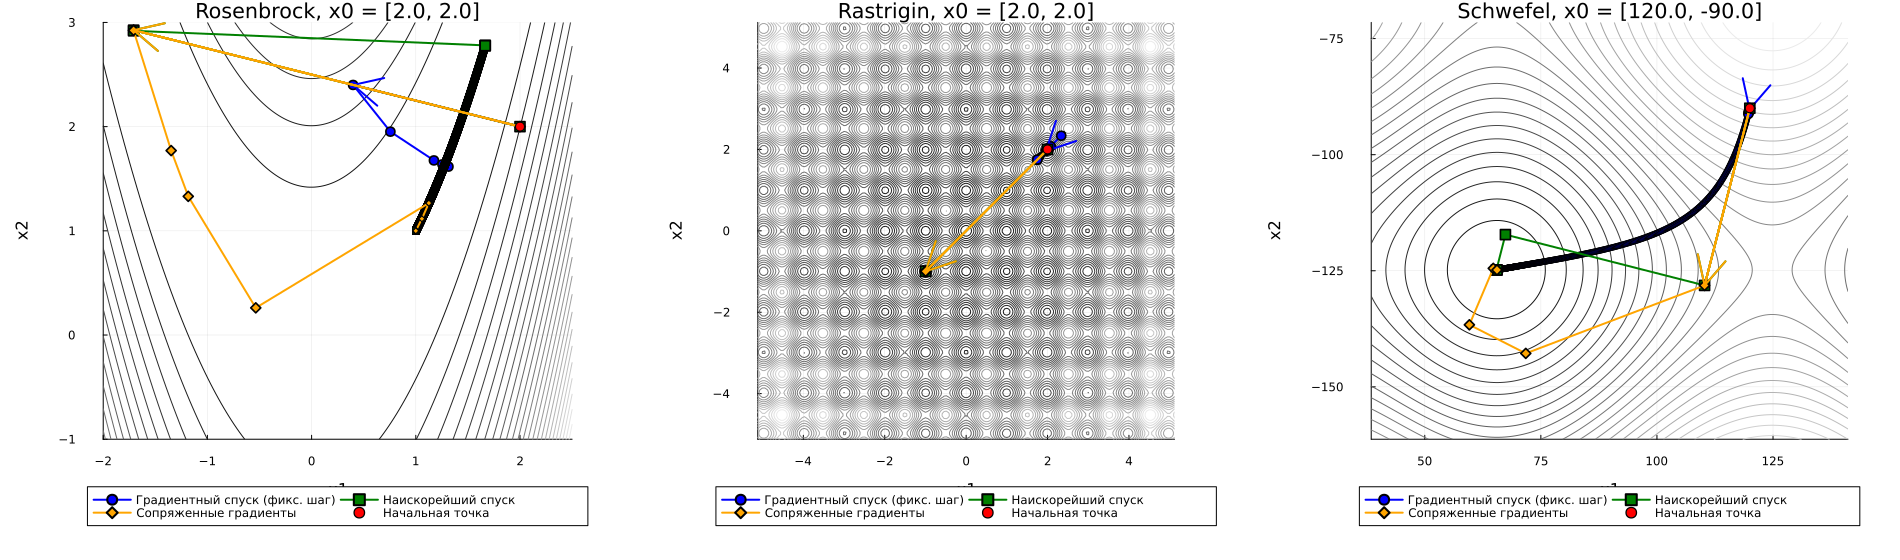

In [9]:
max_iter_nl = 5000
tol_nl = 1e-5

experiments = [
    (
        "Rosenbrock",
        rosenbrock,
        grad_rosenbrock,
        [2.0, 2.0],
        0.001,
        (-2.0, 2.5),
        (-1.0, 3.0),
        false
    ),
    (
        "Rastrigin",
        rastrigin,
        grad_rastrigin,
        [2.0, 2.0],
        0.01,
        (-5.12, 5.12),
        (-5.12, 5.12),
        false
    ),
    (
        "Schwefel",
        schwefel,
        grad_schwefel,
        [120.0, -90.0],
        0.05,
        (-140.0, 140.0),
        (-140.0, 140.0),
        true
    )
]

plots_nl = Any[]

for (name, f_cur, g_cur, x0_cur, fixed_step, xlim_cur, ylim_cur, use_auto_zoom) in experiments
    _, hist_gd = gradient_descent(
        f_cur, g_cur, x0_cur, fixed_step, max_iter_nl, tol_nl;
        run_label="$(name) | Градиентный спуск (фикс. шаг)"
    )
    _, hist_sd = steepest_descent(
        f_cur, g_cur, x0_cur, max_iter_nl, tol_nl;
        run_label="$(name) | Наискорейший спуск"
    )
    _, hist_cg = conjugate_gradient(
        f_cur, g_cur, x0_cur, max_iter_nl, tol_nl;
        run_label="$(name) | Сопряженные градиенты"
    )

    histories = [
        ("Градиентный спуск (фикс. шаг)", hist_gd),
        ("Наискорейший спуск", hist_sd),
        ("Сопряженные градиенты", hist_cg)
    ]

    p = plot_trajectories_on_contour(
        f_cur,
        histories,
        "$(name), x0 = $(x0_cur)";
        xlims=xlim_cur,
        ylims=ylim_cur,
        levels=25,
        grid_n=180,
        auto_zoom=use_auto_zoom,
        zoom_pad=0.35,
        min_span=20.0
    )

    push!(plots_nl, p)
end

plot(plots_nl...; layout=(1, 3), size=(1900, 560))